# Compare the effect of different dataset initialisations

In [1]:
import json

from pydantic import BaseModel

#locals
from src.configs import get_class_list
from src.preprocess import Instance, WLASLClass
from src.run_types import CUTOFF_9_NAMES, CUTOFF_SPLITS, CentreCropConfig, OG_Sampler
from src.stats import (
    AVAIL_SETS,
    AVAIL_SPLITS,
    get_per_instance_stats,
    reverse_preproc_format,
    sort_distribution,
    to_preproc_format,
)
from src.utils import load_rgb_frames_from_video, plt_display_grid
from src.video_dataset import (
    get_labels_path,
    get_transform,
    get_video_path,
    get_wlasl_info,
    load_data_from_json,
)
from src.visualise2 import set_thesis_style


## Set some parameters

In [2]:
set_thesis_style()
verbosity = 1
save_files = False
def printv(*args, level=1, **kwargs):
    if level <= verbosity:
        print(*args, **kwargs)
        
split_idx = 3 #change for different split
set_idx = 0 #change for different set
split_options: list[CUTOFF_SPLITS] = CUTOFF_9_NAMES
set_options: list[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_name: AVAIL_SETS = set_options[set_idx]
classes = get_class_list()
metric = 'num_instances'

## load data

In [3]:
printv(f'Selected: {split_name}')
printv(f'Num classes: {len(classes)}', level=2)

all_sets = {}
tot = 0
for set_name in set_options:
    set_path_info = get_wlasl_info(split_name, set_name)
    set_path = get_labels_path(set_name, set_path_info['labels'], set_path_info['label_suff'])
    all_sets[set_name] = reverse_preproc_format(
        load_data_from_json(set_path, policy="strict"),
        classes)
    printv(f'Num classes of {set_name}: {len(all_sets[set_name])}', level=2)
    tot += len(all_sets[set_name])

printv(all_sets[set_name][0]['gloss'], level=2)
printv(all_sets[set_name][0]['instances'][0], level=2)


Selected: asl2000_cutoff_9


## get stats

In [4]:
all_stats = {}
for key, item in all_sets.items():
    all_stats[key] = get_per_instance_stats([WLASLClass.model_validate(i) for i in item])
  
printv(all_stats[set_name][classes[-1]][metric],level=2)
printv(all_stats[set_name][classes[-1]].keys())

dict_keys(['num_instances', 'length_distribution', 'signers_distribution', 'source_distribution', 'url_distribution', 'variation_distribution'])


### Plotting top and bottom n

In [5]:
import matplotlib.pyplot as plt

from src.visualise2 import plot_bar_chart, split_name_mapper

bins = 20
set_name: AVAIL_SETS = set_options[set_idx]

cls_names = list(all_stats[set_name].keys())
num_inst_distribution = {cls_names.index(k) : all_stats[set_name][k][metric] for k in cls_names}
sorted_num_inst_distribution = sort_distribution(num_inst_distribution)

top_n = list(sorted_num_inst_distribution.items())[-bins:]
bottom_n = list(sorted_num_inst_distribution.items())[:bins]

if verbosity > 1:
    metric_name = f'Top-{bins} most frequent classes'
    unit = 'gloss label'
    _fig, ax = plot_bar_chart(
        [cls_names[i] for i, _ in top_n],
        [count for _, count in top_n],
        title=f"{metric_name.capitalize()} Distribution: {split_name_mapper(split_name)} / {set_name}",
        xlabel=f"{metric_name}{' (' + unit + ')' if unit else ''}",
        ylabel='Count',
        show_values=False,
    )
    plt.show()

if verbosity > 1:
    metric_name = f'Top-{bins} least frequent classes'
    unit = 'gloss label'
    _fig, ax = plot_bar_chart(
        [cls_names[i] for i, _ in bottom_n],
        [count for _, count in bottom_n],
        title=f"{metric_name.capitalize()} Distribution: {split_name_mapper(split_name)} / {set_name}",
        xlabel=f"{metric_name}{' (' + unit + ')' if unit else ''}",
        ylabel='Count',
        show_values=False,
    )
    plt.show()


### Visualising frames from bottom 100

In [6]:
bottom_100_label_nums = [i for i, _ in list(sorted_num_inst_distribution.items())[:100]]
bottom_100_label_names = [classes[i] for i in bottom_100_label_nums]

cls_idx = bottom_100_label_nums[1] # change for different class
split_name = split_options[split_idx]
set_name = set_options[set_idx]

exampler_iterator = iter(all_sets[set_name][cls_idx]['instances'])
idx = 0
tot_samples = len(all_sets[set_name][cls_idx]["instances"])
set_path_info = get_wlasl_info(split_name, set_name)

In [7]:
target_length = 16
frame_size = 224
basic_transform, _, _ = get_transform(
    temporal_aug=[OG_Sampler(target_length=target_length)],
    spatial_aug=[CentreCropConfig(frame_size=frame_size)],
    normalise_to_float=False,
    permute_time_channel=False
)

Example videos for class: "a"
Instance: 1/5
Next example video path: /home/luke/Code/SLR/data/WLASL/WLASL2000/01610.mp4


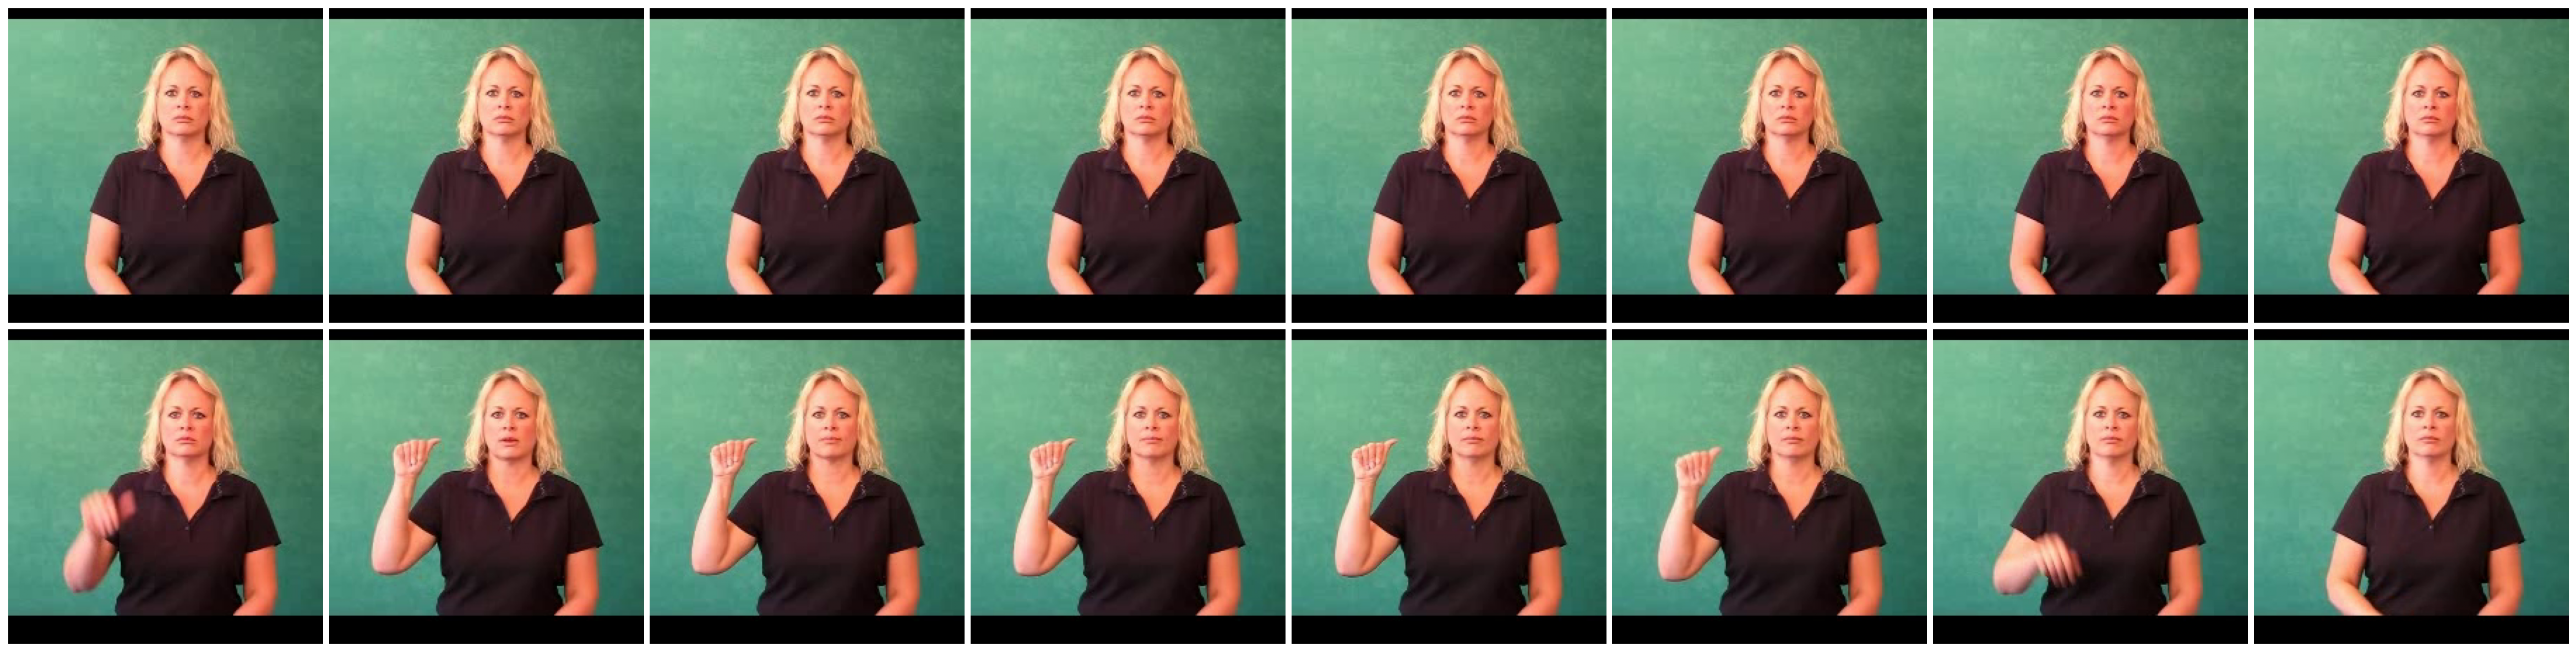

In [8]:
printv(f'Example videos for class: "{classes[cls_idx]}"')
printv(f'Instance: {idx+1}/{tot_samples}')
if idx < tot_samples:
    next_example = Instance.model_validate(next(exampler_iterator))
    ex_path = get_video_path(next_example.video_id, set_path_info['root'])
    
    printv(f'Next example video path: {ex_path}')
    
    plt_display_grid(
        basic_transform(load_rgb_frames_from_video(ex_path, next_example.frame_start, next_example.frame_end)),
        target_length,
    )
else:
    print('No more samples')
    
idx += 1

## Making the bottom 100 dataset

In [9]:
# from pathlib import Path

def _pydantic_default(obj):
    if isinstance(obj, BaseModel):
        return obj.model_dump()

def map_new_labels(instances: list[Instance]) -> list[dict]:
    """Need to remap the labels to be from 0-99 instead of the original label nums
    But want to save the original label nums in the instance info as well for reference
    """
    mapped_instances = []
    for inst in instances:
        original_label_num = inst.label_num
        inst_dict = inst.model_dump()
        inst_dict['original_label_num'] = original_label_num
        inst_dict['label_num'] = bottom_100_label_nums.index(original_label_num)
        mapped_instances.append(inst_dict)
        
    return mapped_instances
        

split_name = 'asl100'
new_split_name = 'asl100_bottom'
new_suffix = 'num_instances.json'
for set_name in set_options:
    bottom_100_subset = to_preproc_format(
        all_sets[set_name],
        criterion=lambda x: x['gloss'] in bottom_100_label_names
    )
    bottom_100_mapped = map_new_labels(bottom_100_subset)
    
    
    
    original_set_path_info = get_wlasl_info(split_name, set_name)
    new_dir = original_set_path_info['labels'].parent / new_split_name 
    # new_dir = Path('preprocessed/labels/asl100_bottom/')
    # assert new_dir.exists() 
    new_path = new_dir / f'{set_name}_{new_suffix}'
    
    new_dir.mkdir(exist_ok=True, parents=True)
    with open(new_path, 'w') as f:
        json.dump(bottom_100_mapped, f, indent=2, default=_pydantic_default)
    printv(f'Saved to: {new_path}')

Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_bottom/train_num_instances.json
Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_bottom/test_num_instances.json
Saved to: /home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100_bottom/val_num_instances.json
